# Singular Value Decomposition

Notebook ini merangkum Chapter 14 dari *Practical Linear Algebra for Data Science*. Chapter ini membahas **Singular Value Decomposition (SVD)** sebagai dekomposisi matrix yang dapat digunakan untuk matrix dengan ukuran apa pun, termasuk nonsquare matrix.

Pembahasan dibuat mengikuti format Chapter 11–13: ada tujuan pembelajaran, ringkasan chapter, struktur pembahasan, penjelasan teori per bagian, rumus matematis yang relevan, kode inti, ringkasan konsep, dan kesimpulan.

## Tujuan Pembelajaran

- Memahami tujuan Singular Value Decomposition.
- Menjelaskan komponen SVD: $U$, $\Sigma$, dan $V^T$.
- Memahami bahwa SVD berlaku untuk matrix ukuran apa pun.
- Menjelaskan hubungan singular values dengan matrix rank.
- Menggunakan `np.linalg.svd()` di Python.
- Membuat singular values matrix $\Sigma$ dari vector singular values.
- Memahami rank-1 layers dan low-rank approximation.
- Menjelaskan hubungan SVD dengan eigendecomposition.
- Mengubah singular values menjadi percent variance explained.
- Memahami condition number sebagai indikator stabilitas numerik.
- Menjelaskan Moore-Penrose pseudoinverse melalui SVD.

## Ringkasan Chapter

Chapter ini memperkenalkan Singular Value Decomposition atau SVD sebagai salah satu dekomposisi paling penting dalam linear algebra. Jika eigendecomposition hanya berlaku untuk square matrix, SVD dapat digunakan pada matrix dengan ukuran apa pun, termasuk rectangular matrix.

SVD menguraikan matrix $A$ menjadi tiga matrix, yaitu $U$, $\Sigma$, dan $V^T$. Matrix $U$ berisi left singular vectors, $\Sigma$ berisi singular values, dan $V^T$ berisi right singular vectors. Singular values selalu real-valued, nonnegative, dan biasanya diurutkan dari terbesar ke terkecil.

Chapter ini juga menjelaskan bahwa SVD mengungkap empat subspaces dari matrix. Left singular vectors berkaitan dengan column space dan left-null space, sedangkan right singular vectors berkaitan dengan row space dan null space. Jumlah singular values yang nonzero sama dengan rank matrix.

Bagian berikutnya membahas cara menggunakan SVD di Python. NumPy mengembalikan singular values sebagai vector, sehingga perlu dibuat matrix $\Sigma$ secara manual jika ingin merekonstruksi matrix. NumPy juga mengembalikan $V^T$, bukan $V$.

Chapter ini kemudian membahas rank-1 layers, yaitu cara melihat matrix sebagai penjumlahan outer product antara singular vectors yang diskalakan oleh singular value. Konsep ini menjadi dasar low-rank approximation, denoising, dan data compression.

Bagian akhir membahas hubungan SVD dengan eigendecomposition, percent variance explained, condition number, dan Moore-Penrose pseudoinverse. Pseudoinverse dapat dihitung melalui SVD dengan membalik singular values yang nonzero.

## Struktur Pembahasan Chapter

| Bagian | Inti Pembahasan |
|---|---|
| The Big Picture of the SVD | Matrix diuraikan menjadi $A=U\Sigma V^T$. |
| Singular Values and Matrix Rank | Rank matrix sama dengan jumlah singular values yang nonzero. |
| SVD in Python | `np.linalg.svd()` menghasilkan $U$, vector singular values, dan $V^T$. |
| Rank-1 Layers | Matrix dapat dipandang sebagai penjumlahan layer rank-1. |
| SVD from EIG | SVD dapat dipahami dari eigendecomposition $AA^T$ dan $A^TA$. |
| Variance Explained | Singular values dapat dinormalisasi menjadi percent variance explained. |
| Condition Number | Rasio singular value terbesar dan terkecil menunjukkan stabilitas numerik. |
| MP Pseudoinverse | Pseudoinverse dihitung dengan membalik singular values yang nonzero. |

## Persiapan Library

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2024)

## The Big Picture of the SVD

Tujuan SVD adalah menguraikan matrix menjadi product dari tiga matrix.

### Rumus Singular Value Decomposition

$$
A = U\Sigma V^T
$$

Keterangan:

- $A$ = matrix asal, dapat berukuran square atau nonsquare
- $U$ = matrix left singular vectors
- $\Sigma$ = diagonal matrix berisi singular values
- $V^T$ = transpose dari matrix right singular vectors

SVD dapat dipahami sebagai generalisasi eigendecomposition untuk nonsquare matrices. Singular values mirip dengan eigenvalues, sedangkan singular vectors mirip dengan eigenvectors.

## Properti Utama SVD

Beberapa properti penting SVD:

| Komponen | Properti |
|---|---|
| $U$ | Square matrix dan orthogonal. |
| $V$ | Square matrix dan orthogonal. |
| $\Sigma$ | Diagonal matrix dengan ukuran sama seperti $A$. |
| Singular values | Selalu real-valued dan nonnegative. |
| Rank | Jumlah singular values yang nonzero. |

Karena $U$ dan $V$ orthogonal, maka:

$$
U^TU=I
$$

dan:

$$
V^TV=I
$$

In [2]:
A = np.random.randn(4, 6)

U, s, Vt = np.linalg.svd(A)

print("A shape :", A.shape)
print("U shape :", U.shape)
print("s shape :", s.shape)
print("Vt shape:", Vt.shape)

print("\nSingular values:")
print(np.round(s, 4))

A shape : (4, 6)
U shape : (4, 4)
s shape : (4,)
Vt shape: (6, 6)

Singular values:
[4.1323 3.3225 1.2868 1.0142]


## Singular Values dan Matrix Rank

Chapter menjelaskan bahwa rank matrix sama dengan jumlah singular values yang nonzero. Dalam praktik komputasi, Python tidak benar-benar mengecek apakah singular value sama dengan nol, tetapi mengecek apakah singular value lebih besar dari tolerance tertentu.

Secara konsep:

$$
rank(A) = \#(\sigma_i > 0)
$$

Keterangan:

- $\sigma_i$ = singular value ke-$i$
- $rank(A)$ = jumlah singular values yang nonzero

Tolerance digunakan karena komputer memiliki precision error, sehingga nilai yang secara teori nol bisa muncul sebagai angka sangat kecil.

In [3]:
A = np.random.randn(5, 3)
A[:, 2] = A[:, 0] + A[:, 1]  # membuat column dependence

s = np.linalg.svd(A, compute_uv=False)

print("Singular values:")
print(np.round(s, 10))

print("\nMatrix rank from NumPy:")
print(np.linalg.matrix_rank(A))

Singular values:
[3.78089753 1.46059269 0.        ]

Matrix rank from NumPy:
2


## SVD in Python

SVD di Python dihitung dengan:

```python
U, s, Vt = np.linalg.svd(A)
```

Ada dua hal penting:

1. Singular values dikembalikan sebagai vector `s`, bukan matrix $\Sigma$.
2. NumPy mengembalikan $V^T$, bukan $V$.

Karena itu, jika ingin merekonstruksi matrix $A$, kita perlu membuat matrix $\Sigma$ dengan ukuran yang sama seperti $A$.

In [4]:
A = np.random.randn(4, 6)

U, s, Vt = np.linalg.svd(A)

S = np.zeros(A.shape)
np.fill_diagonal(S, s)

A_reconstructed = U @ S @ Vt

print("Reconstruction error:")
print(np.linalg.norm(A - A_reconstructed, "fro"))

Reconstruction error:
2.800088867715323e-15


## Visualisasi Komponen SVD

Chapter menampilkan output SVD sebagai beberapa matrix: $A$, $U$, $\Sigma$, dan $V$. Visualisasi seperti ini membantu melihat struktur ukuran dan pola matrix.

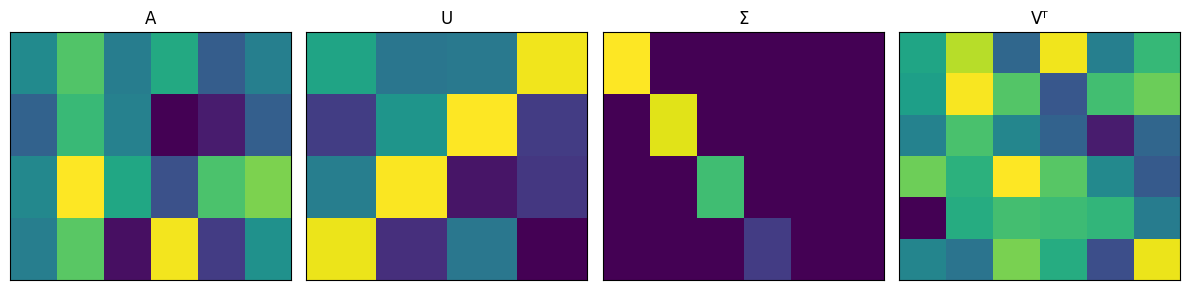

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

items = [
    ("A", A),
    ("U", U),
    ("Σ", S),
    ("Vᵀ", Vt)
]

for ax, (title, mat) in zip(axes, items):
    ax.imshow(mat, aspect="auto")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## SVD and Rank-1 Layers of a Matrix

SVD juga dapat dipahami sebagai penjumlahan beberapa matrix rank-1. Setiap layer dibuat dari outer product antara left singular vector dan right singular vector, kemudian diskalakan oleh singular value.

### Rumus Rank-1 Layer

$$
A_i = u_i\sigma_i v_i^T
$$

Keterangan:

- $A_i$ = layer rank-1 ke-$i$
- $u_i$ = left singular vector ke-$i$
- $\sigma_i$ = singular value ke-$i$
- $v_i^T$ = right singular vector ke-$i$ dalam bentuk row vector

Rekonstruksi matrix dilakukan dengan menjumlahkan semua layer yang singular value-nya nonzero:

$$
A = \sum_{i=1}^{r} u_i\sigma_i v_i^T
$$

Keterangan:

- $r$ = rank matrix

In [6]:
A = np.random.randn(5, 7)
U, s, Vt = np.linalg.svd(A, full_matrices=False)

layers = []

for i in range(len(s)):
    layer_i = np.outer(U[:, i], Vt[i, :]) * s[i]
    layers.append(layer_i)

A_from_layers = np.sum(layers, axis=0)

print("Reconstruction error from rank-1 layers:")
print(np.linalg.norm(A - A_from_layers, "fro"))

Reconstruction error from rank-1 layers:
3.2978078798234776e-15


## Low-Rank Approximation

Kita tidak selalu perlu menggunakan semua layer untuk merekonstruksi matrix. Jika hanya menggunakan $k < r$ layer pertama, hasilnya disebut **low-rank approximation**.

### Rumus Low-Rank Approximation

$$
\tilde{A}_k =
\sum_{i=1}^{k} u_i\sigma_i v_i^T
$$

Keterangan:

- $\tilde{A}_k$ = approximation matrix dengan rank $k$
- $k$ = jumlah layer yang digunakan
- Layer awal lebih penting karena singular values diurutkan dari terbesar ke terkecil

Low-rank approximation digunakan untuk denoising dan data compression.

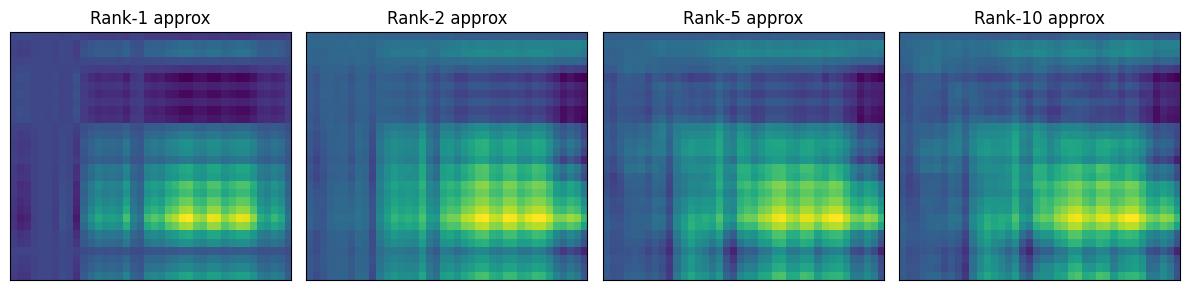

In [7]:
A = np.random.randn(30, 40)

# Buat matrix lebih smooth dengan cumulative sum sederhana agar low-rank approximation terlihat
A = np.cumsum(np.cumsum(A, axis=0), axis=1)

U, s, Vt = np.linalg.svd(A, full_matrices=False)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for ax, k in zip(axes, [1, 2, 5, 10]):
    A_k = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
    ax.imshow(A_k, aspect="auto")
    ax.set_title(f"Rank-{k} approx")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## SVD from EIG

Chapter menjelaskan bahwa SVD dapat dipahami dari eigendecomposition terhadap matrix yang dikalikan dengan transpose-nya.

Untuk left singular vectors:

$$
AA^T = U\Sigma^2U^T
$$

Artinya:

- Eigenvectors dari $AA^T$ adalah left singular vectors $U$.
- Eigenvalues dari $AA^T$ berkaitan dengan squared singular values.

Untuk right singular vectors:

$$
A^TA = V\Sigma^2V^T
$$

Artinya:

- Eigenvectors dari $A^TA$ adalah right singular vectors $V$.
- Singular values berasal dari akar eigenvalues yang sesuai.

Ini menjelaskan mengapa singular values selalu nonnegative dan real-valued.

In [8]:
A = np.random.randn(5, 3)

U, s, Vt = np.linalg.svd(A, full_matrices=False)

evals_AAt, evecs_AAt = np.linalg.eig(A @ A.T)
evals_AtA, evecs_AtA = np.linalg.eig(A.T @ A)

print("Singular values from SVD:")
print(np.round(s, 4))

print("\nSqrt eigenvalues of A.T @ A:")
print(np.round(np.sqrt(np.sort(evals_AtA)[::-1]), 4))

Singular values from SVD:
[3.3712 2.1328 1.3056]

Sqrt eigenvalues of A.T @ A:
[3.3712 2.1328 1.3056]


## SVD of $A^TA$

Jika matrix dapat ditulis sebagai:

$$
S = A^TA
$$

maka $S$ adalah symmetric matrix. Pada symmetric matrix, SVD memiliki hubungan kuat dengan eigendecomposition. Chapter menyatakan bahwa untuk symmetric matrix tertentu, left singular vectors dan right singular vectors dapat sama.

Konsep ini penting untuk PCA karena PCA dapat dilakukan melalui:

- eigendecomposition covariance matrix,
- SVD covariance matrix,
- atau SVD data matrix.

In [9]:
A = np.random.randn(6, 4)
S_mat = A.T @ A

U, s, Vt = np.linalg.svd(S_mat)

print("S symmetric?")
print(np.allclose(S_mat, S_mat.T))

print("\nU and V similarity check via |U.T @ V|:")
V = Vt.T
print(np.round(np.abs(U.T @ V), 3))

S symmetric?
True

U and V similarity check via |U.T @ V|:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


## Converting Singular Values to Variance Explained

Raw singular values berada pada skala numerik matrix. Jika data dikalikan scalar, singular values juga berubah. Karena itu, singular values sering dinormalisasi menjadi percent total variance explained.

### Rumus Percent Variance Explained

$$
\sigma_i^{(\%)} =
\frac{100\sigma_i}{\sum \sigma}
$$

Keterangan:

- $\sigma_i^{(\%)}$ = persentase variance explained oleh singular value ke-$i$
- $\sigma_i$ = singular value ke-$i$
- $\sum \sigma$ = jumlah seluruh singular values

Normalisasi ini memudahkan interpretasi, terutama dalam PCA dan scree plot.

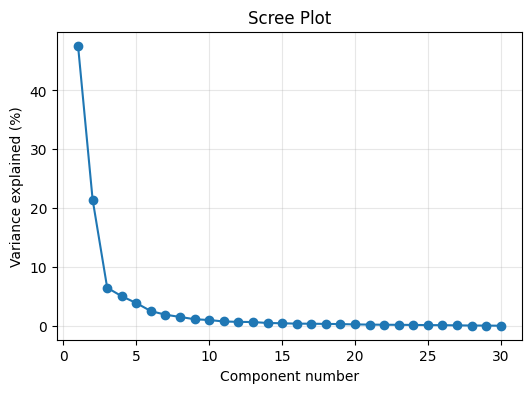

Sum of variance explained: 99.99999999999999


In [10]:
A = np.cumsum(np.cumsum(np.random.randn(30, 40), axis=0), axis=1)

s = np.linalg.svd(A, compute_uv=False)

var_explained = 100 * s / np.sum(s)

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(var_explained)+1), var_explained, "o-")
plt.xlabel("Component number")
plt.ylabel("Variance explained (%)")
plt.title("Scree Plot")
plt.grid(alpha=0.3)
plt.show()

print("Sum of variance explained:", np.sum(var_explained))

## Condition Number

Condition number digunakan untuk mengukur stabilitas numerik sebuah matrix. Condition number didefinisikan sebagai rasio antara singular value terbesar dan terkecil.

### Rumus Condition Number

$$
\kappa =
\frac{\sigma_{\max}}{\sigma_{\min}}
$$

Keterangan:

- $\kappa$ = condition number
- $\sigma_{\max}$ = singular value terbesar
- $\sigma_{\min}$ = singular value terkecil

Condition number yang besar menunjukkan matrix mendekati singular atau ill-conditioned. Matrix seperti ini berisiko menghasilkan inverse atau solusi least squares yang tidak stabil.

In [11]:
A_good = np.random.randn(6, 6)
A_bad = A_good.copy()
A_bad[:, -1] = A_bad[:, 0] + 1e-6*np.random.randn(6)

cond_good = np.linalg.cond(A_good)
cond_bad = np.linalg.cond(A_bad)

print("Condition number of regular matrix:", cond_good)
print("Condition number of ill-conditioned matrix:", cond_bad)

Condition number of regular matrix: 17.292033658147027
Condition number of ill-conditioned matrix: 14481570.596356109


## What to Do About Ill-Conditioned Matrices?

Chapter menekankan bahwa ill-conditioned matrix tidak selalu harus dibuang. Masalahnya bergantung pada konteks dan operasi yang dilakukan. Ill-conditioned matrix terutama menjadi masalah saat menghitung inverse, menyelesaikan system of equations, atau fitting least squares.

Beberapa pendekatan yang dapat dilakukan:

- regularization,
- dimensionality reduction,
- memperbaiki kualitas data,
- memperbaiki feature extraction.

Tidak ada threshold universal yang memisahkan well-conditioned dan ill-conditioned matrix.

## SVD and the Moore-Penrose Pseudoinverse

SVD memberikan cara elegan untuk menghitung inverse dan pseudoinverse. Jika matrix square dan invertible:

$$
A^{-1} = V\Sigma^{-1}U^T
$$

Karena $U$ dan $V$ orthogonal, inverse-nya cukup menggunakan transpose. Untuk diagonal matrix $\Sigma$, inverse diperoleh dengan membalik diagonal elements.

Untuk pseudoinverse, hanya singular values yang nonzero atau lebih besar dari tolerance yang dibalik.

## Rumus Moore-Penrose Pseudoinverse

Pseudoinverse matrix $A$ ditulis sebagai:

$$
A^+ = V\Sigma^+U^T
$$

Keterangan:

- $A^+$ = Moore-Penrose pseudoinverse
- $V$ = right singular vectors
- $\Sigma^+$ = matrix singular values yang sudah dipseudoinverse
- $U^T$ = transpose left singular vectors

Jika singular value sangat kecil, nilainya tidak dibalik karena dapat menyebabkan numerical instability.

In [12]:
def svd_pinv(A, tol=1e-12):
    U, s, Vt = np.linalg.svd(A, full_matrices=False)

    s_inv = np.zeros_like(s)
    s_inv[s > tol] = 1 / s[s > tol]

    return Vt.T @ np.diag(s_inv) @ U.T

A = np.random.randn(5, 3)

pinv_manual = svd_pinv(A)
pinv_numpy = np.linalg.pinv(A)

print("Difference between manual SVD pseudoinverse and NumPy pinv:")
print(np.linalg.norm(pinv_manual - pinv_numpy, "fro"))

Difference between manual SVD pseudoinverse and NumPy pinv:
5.419449386414209e-17


## Pseudoinverse, Left-Inverse, dan Right-Inverse

Chapter menjelaskan bahwa MP pseudoinverse dapat diterapkan pada nonsquare matrix.

Untuk tall full column-rank matrix, pseudoinverse sama dengan left-inverse:

$$
A^+ = (A^TA)^{-1}A^T
$$

Untuk wide full row-rank matrix, pseudoinverse sama dengan right-inverse:

$$
A^+ = A^T(AA^T)^{-1}
$$

In [13]:
# Tall full column-rank matrix
A_tall = np.random.randn(8, 3)

left_inv = np.linalg.inv(A_tall.T @ A_tall) @ A_tall.T
pinv_tall = np.linalg.pinv(A_tall)

print("Tall matrix: pseudoinverse equals left-inverse?")
print(np.allclose(left_inv, pinv_tall))

# Wide full row-rank matrix
A_wide = np.random.randn(3, 8)

right_inv = A_wide.T @ np.linalg.inv(A_wide @ A_wide.T)
pinv_wide = np.linalg.pinv(A_wide)

print("\nWide matrix: pseudoinverse equals right-inverse?")
print(np.allclose(right_inv, pinv_wide))

Tall matrix: pseudoinverse equals left-inverse?
True

Wide matrix: pseudoinverse equals right-inverse?
True


## Ringkasan Konsep Penting

| Konsep | Ringkasan |
|---|---|
| SVD | Dekomposisi matrix menjadi $A=U\Sigma V^T$. |
| $U$ | Left singular vectors, orthogonal matrix. |
| $\Sigma$ | Diagonal matrix berisi singular values. |
| $V^T$ | Transpose dari right singular vectors. |
| Singular values | Nonnegative, real-valued, dan terurut dari besar ke kecil. |
| Matrix rank | Jumlah singular values yang nonzero atau melewati tolerance. |
| Rank-1 layer | Matrix $u_i\sigma_i v_i^T$. |
| Low-rank approximation | Rekonstruksi matrix memakai sebagian layer awal. |
| SVD from EIG | SVD dapat dipahami dari eigendecomposition $AA^T$ dan $A^TA$. |
| Variance explained | Singular values dinormalisasi menjadi persentase kontribusi. |
| Condition number | Rasio singular value terbesar dan terkecil. |
| Ill-conditioned matrix | Matrix dengan condition number besar dan berisiko tidak stabil. |
| MP pseudoinverse | $A^+=V\Sigma^+U^T$. |

## Kesimpulan Chapter

Chapter ini memperkenalkan Singular Value Decomposition sebagai dekomposisi matrix yang sangat penting dalam linear algebra dan data science. Berbeda dari eigendecomposition yang hanya berlaku untuk square matrix, SVD dapat diterapkan pada matrix dengan ukuran apa pun.

SVD menguraikan matrix menjadi $U$, $\Sigma$, dan $V^T$. Matrix $U$ dan $V$ bersifat orthogonal, sedangkan $\Sigma$ berisi singular values yang real-valued, nonnegative, dan diurutkan dari terbesar ke terkecil. Jumlah singular values yang nonzero menentukan rank matrix.

Chapter ini juga menjelaskan bahwa SVD mengungkap struktur subspace matrix. Left singular vectors berkaitan dengan column space dan left-null space, sedangkan right singular vectors berkaitan dengan row space dan null space.

Konsep rank-1 layers menunjukkan bahwa matrix dapat direkonstruksi sebagai penjumlahan outer product singular vectors yang diskalakan oleh singular values. Jika hanya sebagian layer awal yang digunakan, hasilnya adalah low-rank approximation yang berguna untuk denoising dan data compression.

SVD juga berkaitan erat dengan eigendecomposition melalui $AA^T$ dan $A^TA$. Selain itu, singular values dapat digunakan untuk menghitung percent variance explained, condition number, dan Moore-Penrose pseudoinverse. Secara keseluruhan, chapter ini menjadi dasar penting untuk memahami PCA, compression, denoising, numerical stability, dan pseudoinverse dalam data science.